# ResNet CIFAR-10 실습 + CIFAR-100

- 가상환경 생성: `conda create -n resnet_cifar10 python=3.10 -y`

- 주피터 커널을 resnet_cifar10으로 변경.

- 터미널을 사용하면 `conda activate resnet_cifar10` 사용.

### 환경 설정 과정

In [1]:
!python3 -c "import sys; print('Python version:', sys.version)"

Python version: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]


In [2]:
# !conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia -y


In [3]:
# !conda install -n resnet_cifar10 mkl mkl-include -y

In [4]:
#!conda list

In [5]:
# !conda install mkl==2024.0.0 -c conda-forge -y

In [6]:
# !conda uninstall pytorch torchvision torchaudio pytorch-cuda -y

# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [7]:
#!ls

In [8]:
# !cd ..
# !ls

In [9]:
# !pip uninstall torch torchvision torchaudio -y
# !conda uninstall pytorch torchvision torchaudio pytorch-cuda -y

# !rm -rf ~/miniconda3/envs/resnet_cifar10/lib/python3.10/site-packages/torch*

# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [10]:
# !pip install matplotlib

### Import 및 세팅

In [11]:
import torch
print(torch.cuda.is_available())

True


In [12]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


### Hyper Parameters & Settings

In [14]:
batch_size = 256
LR = 0.1 # 32k과 48k에서 낮춰줘야함

### Data

In [15]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

# 1. CIFAR-100 고유의 평균과 표준편차 값
mean_cifar100 = (0.5071, 0.4867, 0.4408)
std_cifar100 = (0.2675, 0.2565, 0.2761)

# 데이터 증강 및 정규화 적용
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean_cifar100, std_cifar100)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_cifar100, std_cifar100)
])

class CustomCIFAR100(Dataset):
    def __init__(self, root, train=True, transform=None, download=True):
        self.dataset = datasets.CIFAR100(root=root, train=train, download=download)
        self.transform = transform
        self.classes = self.dataset.classes 

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

train_DS = CustomCIFAR100(root='~/resnet_cifar100/data', train=True, download=True, transform=transform_train)
test_DS = CustomCIFAR100(root='~/resnet_cifar100/data', train=False, download=True, transform=transform_test)

Files already downloaded and verified
Files already downloaded and verified


In [16]:
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=batch_size, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=batch_size, shuffle=False)

In [17]:
print(train_DS.classes)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8974658..1.4813515].


torch.Size([256, 3, 32, 32])
라벨 이름: streetcar


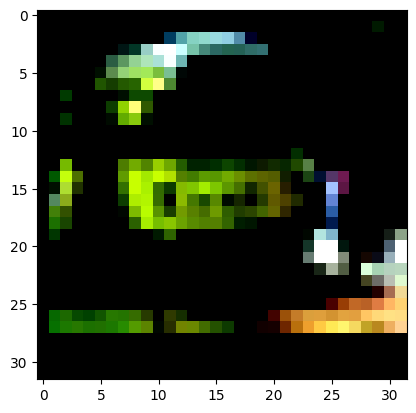

In [25]:
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)

plt.imshow(x_batch[0].permute(1,2,0))
print("라벨 이름:", test_DS.classes[y_batch[0]])

- Residual Block 내부 정의

In [19]:
# ResNet은 기본적으로 아래와 같은 Residual Block 매우 많이 쌓기(아마 논문에 있는 56개 레이어를 쌓을 듯) 때문에 일단 클래스로 만들고 나중에 계속 활용.
class Residual_Block(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1, padding=1): # 디폴트 값은 이렇게
        super().__init__()

        self.stride = stride
        self.padding = padding
        self.input_channels = input_channels
        self.output_channels = output_channels

        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=stride, padding=padding, bias=False) # 커널 사이즈는 항상 3개 쓸 듯?
        self.bn1 = nn.BatchNorm2d(output_channels) # 논문에서 쓰라고 함
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu2 = nn.ReLU()

    # 여기가 핵심임!
    def forward(self, x):
        identity = x # 원래 입력값을 identity라고 함, 일단 여기에 저장.

        # 잔차 함수 통과 (F(x))
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # 만약 인풋과 아웃풋이 다르면 원래는 정사영시키는게 맞지만, 그냥 stride 2로 사이즈 줄이고 패딩으로 채워서 맞춰버리기
        if self.stride != 1 or self.input_channels != self.output_channels:
            identity = identity[:, :, ::2, ::2]
            pad_channels = self.output_channels - self.input_channels
            identity = F.pad(identity, (0,0,0,0,0, pad_channels))

        out += identity # F(x) + x

        out = self.relu2(out) # 마지막으로 relu 통과

        return out


- 메인 신경망 정의

In [20]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 시작 부분
        self.conv1 = nn.Conv2d(3,16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()

        # 반복구간
        blocks1 = []
        for _ in range(9):
            blocks1.append(Residual_Block(16,16, stride=1, padding=1))
        self.layer1 = nn.Sequential(*blocks1) # 리스트 형식으로 블록들을 다 때려넣음
        
        blocks2 = []
        blocks2.append(Residual_Block(16,32, stride=2))
        for _ in range(8):
            blocks2.append(Residual_Block(32,32, stride=1))
        self.layer2 = nn.Sequential(*blocks2)

        blocks3 = []
        blocks3.append(Residual_Block(32,64, stride=2))
        for _ in range(8):
            blocks3.append(Residual_Block(64,64, stride=1))
        self.layer3 = nn.Sequential(*blocks3)

        # 끝부분
        self.avgpool = nn.AdaptiveAvgPool2d((1,1)) # GAP!
        self.fc1 = nn.Linear(64,100)
        self.fc2 = nn.Linear(100,100)

    def forward(self, x):
        # 초반 입력
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # Residual 반복 구간
        x = self.layer1(x) # 
        x = self.layer2(x)
        x = self.layer3(x)

        # 마무리 구간
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


- 모델 인스턴스 만들고 GPU에 올리기

In [21]:
model = ResNet().to(DEVICE)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay= 0.0001) # 논문에서 쓰라고 함

max_iterations = 64000 # 논문에서 그렇게함
# max_iterations = 32000

warmup_iterations = 1000

- ResNet 논문에도 적혀있긴하지만, 현재도 웜업을 많이 사용한다고 함. 처음에 커다란 가중치로 인해 어뚱한 방향으로 모델이 너무 멀리 점프해버리면 기울기 폭발이 발생할 수 있기 때문임.
- 그래서 첫 1000개의 iteration 정도는 서서히 lr을 늘림.

In [24]:
total_iterations = 0
epoch = 0


while total_iterations < max_iterations:
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_DL:
        # 웜업 단계 추가
        if total_iterations < warmup_iterations:
            if total_iterations == 0:
                print("신경망이 식전 에피타이저를 먹고 있습니다... (워밍업)")
            current_lr = 0.01 + (LR - 0.01) * (total_iterations / warmup_iterations)
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr
        elif total_iterations == warmup_iterations:
            print("앙트레 종료, 이제 제대로 학습 시작")
            for param_group in optimizer.param_groups:
                param_group['lr'] = LR
        
        # 논문에 쓰인대로 32k, 48k에서 LR 낮추기
        elif total_iterations == 32000:
            print("========LR을 0.01로 감소시킵니다========")
            for param_group in optimizer.param_groups:
                param_group['lr'] = 0.01 # lr 수정
        elif total_iterations == 48000:
            print("========LR을 0.001로 감소시킵니다=======")
            for param_group in optimizer.param_groups:
                param_group['lr'] = 0.001

        # 64k에서 학습 끝내기
        if total_iterations >= max_iterations:
            break

        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)

        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        total_iterations += 1

        if total_iterations % 100 == 0:
            print(f"epoch: {epoch}, iteration: {total_iterations}/{max_iterations}, loss: {loss.item():.4f}")

    epoch += 1

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    # eval
    with torch.no_grad():
        for test_inputs, test_targets in test_DL:
            test_inputs, test_targets = test_inputs.to(DEVICE), test_targets.to(DEVICE)

            test_outputs = model(test_inputs)
            loss = criterion(test_outputs, test_targets)
            
            test_loss += loss.item()
            _, test_predicted = test_outputs.max(1)
            test_total += test_targets.size(0)
            test_correct += test_predicted.eq(test_targets).sum().item()
    test_acc = 100. * test_correct / test_total
    train_acc = 100. * correct / total
    print(f"에포크 {epoch} 끝, train acc: {train_acc:.2f}, test acc: {test_acc:.2f}")

print("학습 끝!")

신경망이 식전 에피타이저를 먹고 있습니다... (워밍업)
epoch: 0, iteration: 100/64000, loss: 0.4044
에포크 1 끝, train acc: 86.30, test acc: 67.53
epoch: 1, iteration: 200/64000, loss: 0.3470
epoch: 1, iteration: 300/64000, loss: 0.4520
에포크 2 끝, train acc: 87.39, test acc: 66.71
epoch: 2, iteration: 400/64000, loss: 0.4265
epoch: 2, iteration: 500/64000, loss: 0.4819
에포크 3 끝, train acc: 86.14, test acc: 64.39
epoch: 3, iteration: 600/64000, loss: 0.4913
epoch: 3, iteration: 700/64000, loss: 0.4313
에포크 4 끝, train acc: 83.59, test acc: 59.26
epoch: 4, iteration: 800/64000, loss: 0.5333
epoch: 4, iteration: 900/64000, loss: 0.5854
에포크 5 끝, train acc: 80.12, test acc: 54.69
epoch: 5, iteration: 1000/64000, loss: 0.5962
앙트레 종료, 이제 제대로 학습 시작
epoch: 5, iteration: 1100/64000, loss: 0.7126
에포크 6 끝, train acc: 78.23, test acc: 56.81
epoch: 6, iteration: 1200/64000, loss: 0.6700
epoch: 6, iteration: 1300/64000, loss: 0.5913
에포크 7 끝, train acc: 78.46, test acc: 59.54
epoch: 7, iteration: 1400/64000, loss: 0.6592
epoch: 7, i

- 모델 저장

In [26]:
import os
save_path = os.path.expanduser("~/resnet_cifar100/resnet56_cifar100_weights.pth")
torch.save(model.state_dict(), save_path)


- inference

실제 정답: poppy
모델 예측: poppy


/tmp/ipykernel_63789/4194720956.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(save_path))


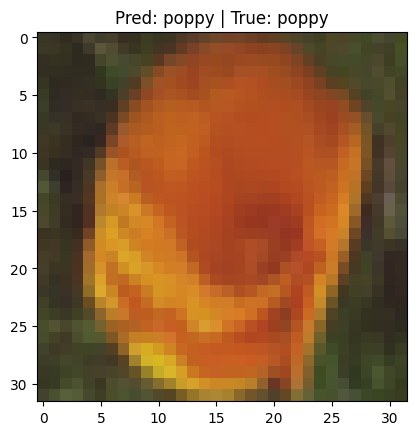

In [27]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

loaded_model = ResNet().to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path))
loaded_model.eval()

random_idx = random.randint(0, len(test_DS) - 1)
single_image, true_label = test_DS[random_idx]
single_image_gpu = single_image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = loaded_model(single_image_gpu)
    _, predicted = output.max(1)
    pred_label = predicted.item()

print(f"실제 정답: {test_DS.classes[true_label]}")
print(f"모델 예측: {test_DS.classes[pred_label]}")

# 역 정규화
img_for_plot = single_image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2023, 0.1994, 0.2010])

img_for_plot = std * img_for_plot + mean

img_for_plot = np.clip(img_for_plot, 0, 1)

plt.imshow(img_for_plot)
plt.title(f"Pred: {test_DS.classes[pred_label]} | True: {test_DS.classes[true_label]}")
plt.show()

- 근데 이 분들은 수동으로 이걸 조절하셨는데.. 그냥 ADAM을 쓰면 되는거 아님??
    - 대회에서 나온 결론인데, CNN 이미지 분류에 한정해서는 ADAM을 쓰는 것보다 SGD + Momentum + 수동 Learning Rate 스케줄링(Step Decay) 조합이 Adam보다 일반화(Generalization) 성능이 더 좋게 나오는 경향이 있다고함.

- 순정

32k에 test acc 74.72%, 64k 부근에 너무 train이 100%에 수렴해서 훈련하는 의미 퇴색.

- 증강 적용 (1/3 시간에 비슷한 성능 도착)

epoch: 27, iteration: 10900/32000, loss: 0.5744

에포크 28 끝, train acc: 76.54, test acc: 74.64

...

epoch: 40, iteration: 16000/32000, loss: 0.5608

에포크 41 끝, train acc: 80.35, test acc: 79.73

...

epoch: 81, iteration: 32000/32000, loss: 0.5017

에포크 82 끝, train acc: 84.17, test acc: 82.58

- 웜업 추가 및 MLP 레이어 하나 추가 (일단 초반 속도는 압도적임, 이전 모델의 거의 1/6만큼의 시간 안에 비슷한 성능까지 옴)

에포크 16 끝, train acc: 78.23, test acc: 74.96

epoch: 16, iteration: 1600/64000, loss: 0.6446

epoch: 653, iteration: 64000/64000, loss: 0.0112

에포크 654 끝, train acc: 99.48, test acc: 89.49 # 3시간 걸림

학습 끝!